# PROJECT: Motion Security System

---

## What Are We Building?

A **real-time security camera system** that:
- Detects motion using **Background Subtraction**
- Tracks moving objects with **contour detection**
- Ignores activity outside a **Region of Interest (ROI)** — only watch the door, not the whole room
- **Saves video clips** automatically when motion is detected
- Writes a **timestamped event log** (CSV file)

This is exactly how commercial CCTV systems work!

---

## Project Architecture

```
Video / Webcam
     |
     v
 [ROI Masking]          <- Only watch a specific zone
     |
     v
 [Background Subtraction]  <- Separate moving objects from static background
     |
     v
 [Noise Filtering]      <- Remove small specks (morphological ops)
     |
     v
 [Contour Detection]    <- Find shape and location of each moving object
     |
     v
 [Alert & Recording]    <- Save clip + log event when motion is large enough
```

## Topics
1. Background Subtraction (MOG2 and KNN)
2. Noise Filtering with Morphological Operations
3. Contour Detection and Bounding Boxes
4. Region of Interest (ROI) Masking
5. Alert State Machine (min-frames + cooldown)
6. Video Clip Saving with cv2.VideoWriter
7. Complete Security System (all combined)
8. Offline Demo (no webcam needed)

---
# Part 1: Background Subtraction

## The Core Idea

A static camera sees mostly the same scene (the **background**).  
When something **moves**, those pixels look different from the background model.  
Background subtraction builds a model of the empty scene, then marks anything different as **foreground** (motion).

```
Frame t:    empty room            Background model
Frame t+1:  person enters  -->   FOREGROUND MASK shows person
```

## Two Methods in OpenCV

### 1. MOG2 (Mixture of Gaussians v2) — most popular
- Models each pixel as a **mixture of Gaussians** (probability distributions)
- Adapts automatically to slow background changes (lighting, shadows)
- Detects shadows separately (shown as gray=127 in the mask)

```python
bg = cv2.createBackgroundSubtractorMOG2(
    history=500,         # how many past frames build the model
    varThreshold=50,     # how different a pixel must be to count as foreground
    detectShadows=True   # shadows appear gray (127), not white (255)
)
mask = bg.apply(frame)   # 0=background, 127=shadow, 255=foreground
```

### 2. KNN (K-Nearest Neighbours) — faster for stable backgrounds
```python
bg = cv2.createBackgroundSubtractorKNN(history=500, dist2Threshold=400)
mask = bg.apply(frame)
```

## The Math (simplified MOG2 intuition)

For each pixel, maintain a model with mean $\mu$ and std $\sigma$.  
A pixel is **foreground** if:

$$|I(x,y) - \mu| > k \cdot \sigma$$

Where k = threshold (the `varThreshold` parameter).

Training background models on 100 frames...


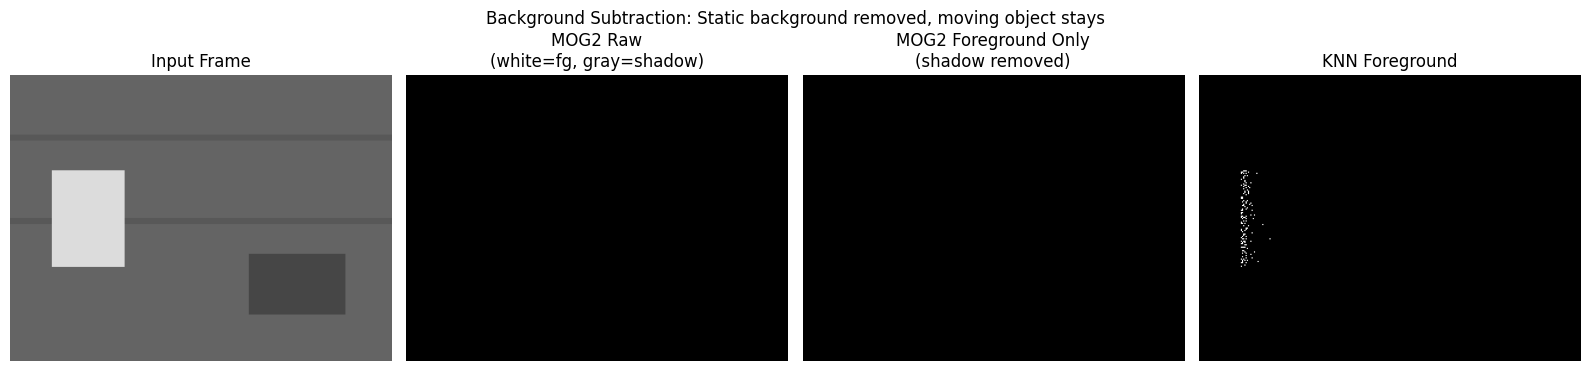

White pixels = detected foreground (the moving object).
Black pixels = background (static parts of the scene).


In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Simulate frames: static gray background + moving white rectangle
def make_frame(idx, h=240, w=320):
    frame = np.ones((h, w, 3), dtype=np.uint8) * 100  # gray background
    # Horizontal lines (texture)
    frame[50:55, :] = 88
    frame[120:125, :] = 88
    # Moving object: slides across the frame
    x = 10 + (idx * 5) % (w - 70)
    cv2.rectangle(frame, (x, 80), (x+60, 160), (220, 220, 220), -1)
    # Static object (always there -- should stay in background)
    cv2.rectangle(frame, (200, 150), (280, 200), (70, 70, 70), -1)
    return frame

# Create two subtractors
bg_mog2 = cv2.createBackgroundSubtractorMOG2(history=200, varThreshold=40, detectShadows=True)
bg_knn  = cv2.createBackgroundSubtractorKNN(history=200, dist2Threshold=300, detectShadows=True)

# Training phase: feed 100 frames so the model learns the background
print('Training background models on 100 frames...')
for i in range(100):
    f = make_frame(i)
    bg_mog2.apply(f)
    bg_knn.apply(f)

# Test on a frame with a moving object
test = make_frame(105)
mask_mog2 = bg_mog2.apply(test)
mask_knn  = bg_knn.apply(test)

# Remove shadows: keep only true foreground (255), not shadows (127)
_, fg_mog2 = cv2.threshold(mask_mog2, 200, 255, cv2.THRESH_BINARY)
_, fg_knn  = cv2.threshold(mask_knn,  200, 255, cv2.THRESH_BINARY)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(cv2.cvtColor(test, cv2.COLOR_BGR2RGB))
axes[0].set_title('Input Frame')
axes[1].imshow(mask_mog2, cmap='gray')
axes[1].set_title('MOG2 Raw\n(white=fg, gray=shadow)')
axes[2].imshow(fg_mog2, cmap='gray')
axes[2].set_title('MOG2 Foreground Only\n(shadow removed)')
axes[3].imshow(fg_knn, cmap='gray')
axes[3].set_title('KNN Foreground')
for ax in axes: ax.axis('off')
plt.suptitle('Background Subtraction: Static background removed, moving object stays', fontsize=12)
plt.tight_layout()
plt.savefig('bg_subtraction.png', dpi=100)
plt.show()
print('White pixels = detected foreground (the moving object).')
print('Black pixels = background (static parts of the scene).')

---
# Part 2: Noise Filtering the Foreground Mask

## The Problem

Background subtraction produces a **noisy mask** — tiny white speckles appear
even in areas with no real motion (camera sensor noise, compression artifacts).  
Without filtering these, we would get constant false alarms.

## Solution: Morphological Operations

Morphological operations work on binary (black/white) images using a **kernel** (small shape).

| Operation | Effect | Use |
|-----------|--------|-----|
| **Erosion** | Shrinks white blobs | Removes small noise specks |
| **Dilation** | Grows white blobs | Fills holes, merges nearby blobs |
| **OPEN** (erode then dilate) | Removes small noise | Best first step |
| **CLOSE** (dilate then erode) | Fills holes | Fixes broken objects |

## Code

```python
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# Step 1: Remove noise
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

# Step 2: Fill holes inside detected objects
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# Step 3: Grow blobs so nearby pieces merge
mask = cv2.dilate(mask, kernel, iterations=2)
```

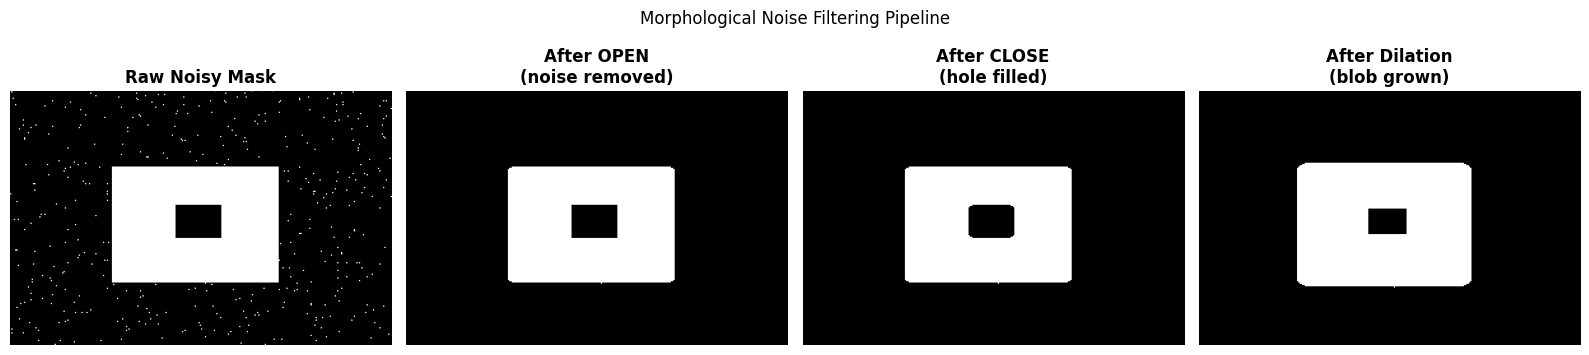

Morphological operations remove noise without removing the real object.


In [13]:
import cv2, numpy as np, matplotlib.pyplot as plt

# Create a noisy foreground mask (simulating raw BG subtraction output)
np.random.seed(42)
noisy = np.zeros((200, 300), dtype=np.uint8)

# Real object (large blob = person)
cv2.rectangle(noisy, (80, 60), (210, 150), 255, -1)

# Add random noise specks
idx = np.random.randint(0, 200*300, 500)
noisy.flat[idx] = 255

# Add a hole inside the real object
cv2.rectangle(noisy, (130, 90), (165, 115), 0, -1)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

opened  = cv2.morphologyEx(noisy, cv2.MORPH_OPEN,  kernel)  # kill noise
closed  = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)  # fill hole
final   = cv2.dilate(closed, kernel, iterations=1)            # grow blob

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, title in zip(axes,
    [noisy, opened, closed, final],
    ['Raw Noisy Mask', 'After OPEN\n(noise removed)',
     'After CLOSE\n(hole filled)', 'After Dilation\n(blob grown)']):
    ax.imshow(img, cmap='gray'); ax.set_title(title, fontweight='bold'); ax.axis('off')
plt.suptitle('Morphological Noise Filtering Pipeline', fontsize=12)
plt.tight_layout()
plt.savefig('noise_filter.png', dpi=100)
plt.show()
print('Morphological operations remove noise without removing the real object.')

---
# Part 3: Contour Detection and Bounding Boxes

## What Are Contours?

Contours are the **outlines** of connected white regions in a binary image.  
After cleaning the foreground mask, we find contours to:
- Know **where** each object is
- Know **how big** it is (area in pixels)
- Draw bounding boxes around it

## Code Pattern

```python
# Find all contours
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    area = cv2.contourArea(cnt)    # size of blob
    if area < 500:                  # skip tiny noise
        continue

    x, y, w, h = cv2.boundingRect(cnt)   # bounding box
    cv2.rectangle(frame, (x,y), (x+w,y+h), (0,255,0), 2)

    # Center of the object
    cx, cy = x + w//2, y + h//2
    cv2.circle(frame, (cx, cy), 5, (0,0,255), -1)
```

## Key Functions

| Function | Returns | Use |
|----------|---------|-----|
| `cv2.findContours()` | List of contours | Find all blobs |
| `cv2.contourArea()` | float (pixels^2) | Filter tiny blobs |
| `cv2.boundingRect()` | (x, y, w, h) | Draw box around object |
| `cv2.drawContours()` | draws in-place | Show exact outline |

Contours found: 3
#    Area (px^2)     Action
------------------------------------------
1    225             SKIP (noise)
2    5490            DETECT -> ALERT
3    9000            DETECT -> ALERT


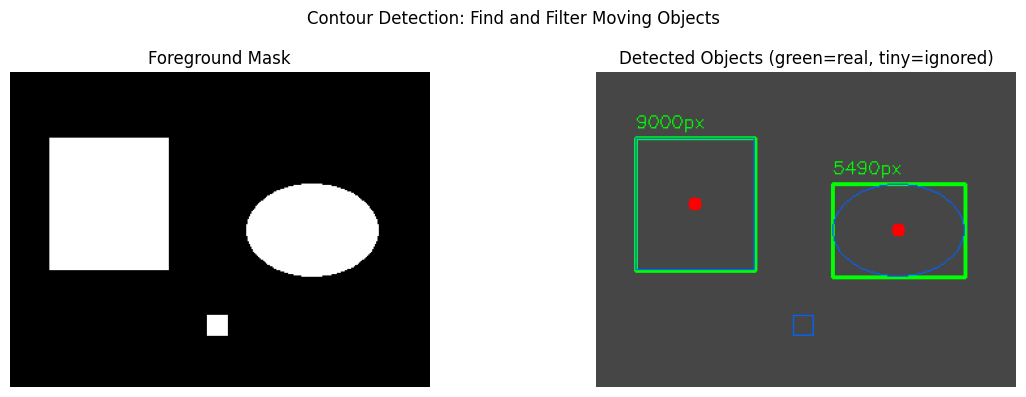

In [14]:
import cv2, numpy as np, matplotlib.pyplot as plt

# Create a binary mask with objects of different sizes
mask = np.zeros((240, 320), dtype=np.uint8)
cv2.rectangle(mask, (30, 50),   (120, 150), 255, -1)       # large: person
cv2.ellipse(mask, (230, 120), (50, 35), 0, 0, 360, 255, -1) # medium: car
cv2.rectangle(mask, (150, 185), (165, 200), 255, -1)        # tiny: noise

frame = np.ones((240, 320, 3), dtype=np.uint8) * 70  # dark background
display = frame.copy()

contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

MIN_AREA = 400
print(f'Contours found: {len(contours)}')
print(f'{"#":<5}{"Area (px^2)":<16}{"Action"}')
print('-' * 42)

for i, cnt in enumerate(contours):
    area = cv2.contourArea(cnt)
    if area < MIN_AREA:
        print(f'{i+1:<5}{area:<16.0f}SKIP (noise)')
        continue
    print(f'{i+1:<5}{area:<16.0f}DETECT -> ALERT')
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(display, (x,y), (x+w,y+h), (0,255,0), 2)
    cv2.putText(display, f'{area:.0f}px', (x, y-8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,255,0), 1)
    cv2.circle(display, (x+w//2, y+h//2), 5, (0,0,255), -1)

cv2.drawContours(display, contours, -1, (255,100,0), 1)

fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].imshow(mask, cmap='gray'); axes[0].set_title('Foreground Mask'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(display, cv2.COLOR_BGR2RGB))
axes[1].set_title('Detected Objects (green=real, tiny=ignored)'); axes[1].axis('off')
plt.suptitle('Contour Detection: Find and Filter Moving Objects', fontsize=12)
plt.tight_layout(); plt.savefig('contours.png', dpi=100); plt.show()

---
# Part 4: Region of Interest (ROI) Masking

## Why Mask an ROI?

In a real security setup you only care about specific zones:
- A swaying tree outside the window -> **ignore** (outside ROI)
- Someone walking through the **door** -> **alert!** (inside ROI)

ROI masking lets you define exactly which pixels to monitor.

## How It Works

1. Create a **black image** (same size as frame)
2. Draw **white shapes** where you want to watch (the ROI zone)
3. `cv2.bitwise_and` with the foreground mask keeps only the intersection

```python
# Step 1+2: create ROI mask (white = watch, black = ignore)
roi = np.zeros(frame.shape[:2], dtype=np.uint8)
# Rectangular zone:
cv2.rectangle(roi, (100, 50), (400, 300), 255, -1)
# OR a polygonal zone:
pts = np.array([[50,100],[200,50],[350,200],[50,200]])
cv2.fillPoly(roi, [pts], 255)

# Step 3: apply
fg_in_roi = cv2.bitwise_and(fg_mask, fg_mask, mask=roi)
```

**bitwise_and** keeps a pixel white only if it is white in BOTH images.

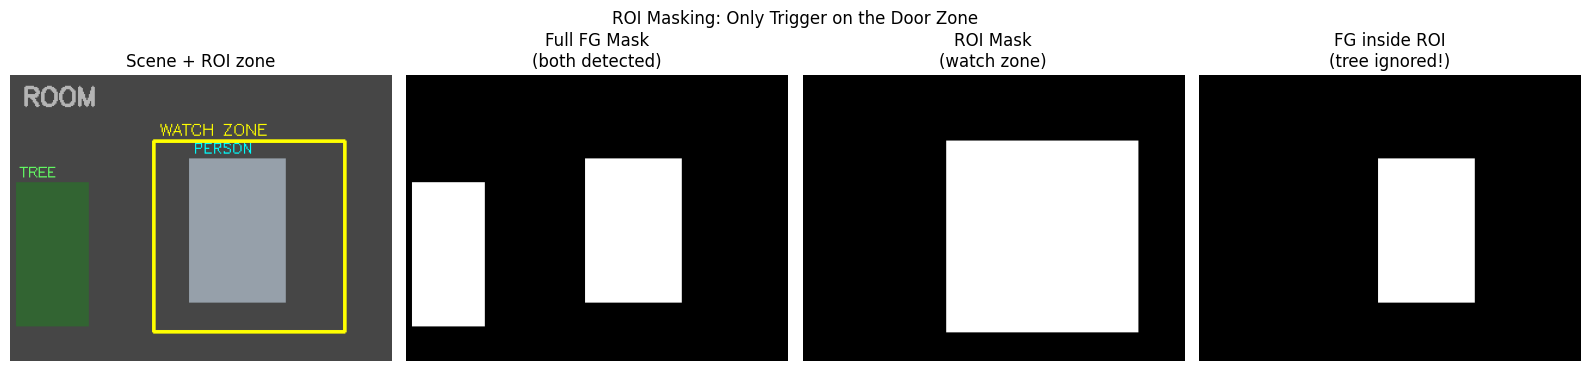

The tree (left) is filtered OUT. Only the person (door zone) triggers alerts.


In [15]:
import cv2, numpy as np, matplotlib.pyplot as plt

H, W = 240, 320

# Scene with two objects: person at the door (ROI) and tree outside (not ROI)
frame = np.ones((H, W, 3), dtype=np.uint8) * 70
cv2.putText(frame, 'ROOM', (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (180,180,180), 2)

# Person at door
cv2.rectangle(frame, (150, 70), (230, 190), (170,160,150), -1)
cv2.putText(frame, 'PERSON', (153, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,0), 1)

# Tree outside (left edge of frame)
cv2.rectangle(frame, (5, 90), (65, 210), (50,100,50), -1)
cv2.putText(frame, 'TREE', (8, 85), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (100,255,100), 1)

# Foreground mask: both objects detected as motion
full_fg = np.zeros((H, W), dtype=np.uint8)
cv2.rectangle(full_fg, (150, 70), (230, 190), 255, -1)
cv2.rectangle(full_fg, (5, 90),  (65, 210),  255, -1)

# ROI: only the door zone
roi_mask = np.zeros((H, W), dtype=np.uint8)
door = np.array([[120,55],[280,55],[280,215],[120,215]], dtype=np.int32)
cv2.fillPoly(roi_mask, [door], 255)

# Apply ROI
fg_roi = cv2.bitwise_and(full_fg, full_fg, mask=roi_mask)

# Draw ROI on frame
vis = frame.copy()
cv2.polylines(vis, [door], True, (0,255,255), 2)
cv2.putText(vis, 'WATCH ZONE', (125, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,255,255), 1)

fig, axes = plt.subplots(1,4, figsize=(16,4))
axes[0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); axes[0].set_title('Scene + ROI zone')
axes[1].imshow(full_fg, cmap='gray'); axes[1].set_title('Full FG Mask\n(both detected)')
axes[2].imshow(roi_mask, cmap='gray'); axes[2].set_title('ROI Mask\n(watch zone)')
axes[3].imshow(fg_roi, cmap='gray'); axes[3].set_title('FG inside ROI\n(tree ignored!)')
for ax in axes: ax.axis('off')
plt.suptitle('ROI Masking: Only Trigger on the Door Zone', fontsize=12)
plt.tight_layout(); plt.savefig('roi_masking.png', dpi=100); plt.show()
print('The tree (left) is filtered OUT. Only the person (door zone) triggers alerts.')

---
# Part 5: Alert State Machine

## The Problem with Naive Alerting

If we alert every time any foreground pixel appears, we get:
- **False positives**: camera noise, a sudden light change
- **Alert spam**: 25 alerts per second for one person walking by

## Solution: 3 Filters

| Filter | What it does | Parameter |
|--------|-------------|----------|
| **Minimum area** | Ignore tiny blobs | `MIN_CONTOUR_AREA` |
| **Minimum duration** | Require N consecutive motion frames | `MIN_ALERT_FRAMES` |
| **Cooldown** | Wait X seconds between alerts | `COOLDOWN_SEC` |

## State Diagram

```
  IDLE
   |--- motion for >= MIN_FRAMES and not in cooldown --->
  ALERT (start recording, log event)
   |
  RECORDING
   |--- motion stops, wait POST_BUFFER_SEC ---> SAVING -> IDLE
```

In [16]:
import datetime, time

class AlertSystem:
    """
    Three-filter alert state machine for motion detection.
    - min_area:     ignore blobs smaller than this (pixels^2)
    - min_frames:   require this many consecutive frames with motion
    - cooldown_sec: wait this long before next alert
    """
    def __init__(self, min_area=800, min_frames=4, cooldown_sec=8):
        self.min_area     = min_area
        self.min_frames   = min_frames
        self.cooldown_sec = cooldown_sec
        self.motion_count = 0    # consecutive frames with motion
        self.alerting     = False
        self.last_alert_t = 0
        self.events       = []   # list of alert events

    def update(self, max_area, current_time):
        """
        Update with the largest contour area found this frame.
        Returns: 'idle', 'alert', 'recording', or 'cooldown'
        """
        has_motion = max_area >= self.min_area
        in_cooldown = (current_time - self.last_alert_t) < self.cooldown_sec

        if has_motion:
            self.motion_count += 1
        else:
            self.motion_count = 0
            self.alerting = False  # motion stopped

        # Trigger alert?
        if self.motion_count >= self.min_frames and not in_cooldown:
            if not self.alerting:
                self.alerting = True
                self.last_alert_t = current_time
                ts = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
                self.events.append({'time': ts, 'area': max_area})
                return 'alert'
            return 'recording'

        if in_cooldown and has_motion:
            return 'cooldown'
        return 'idle'


# Simulate 55 frames
sys = AlertSystem(min_area=800, min_frames=3, cooldown_sec=5)

#              frames 0-9 no motion | 10-17 motion | 18-22 gone | 23-26 tiny noise | 27-31 gap | 32-41 motion
areas = [0]*10 + [1500]*8 + [0]*5 + [200]*4 + [0]*5 + [2000]*10

print(f'Settings: min_area={sys.min_area}, min_frames={sys.min_frames}, cooldown={sys.cooldown_sec}s')
print(f'{"Frame":<8}{"Area":<10}{"State"}')
print('-' * 35)
for i, area in enumerate(areas):
    t = i * 0.04   # 25 fps
    state = sys.update(area, t)
    flag = ' <<< ALERT!' if state == 'alert' else ''
    print(f'{i:<8}{area:<10}{state}{flag}')

print(f'\nTotal alert events: {len(sys.events)}')
for ev in sys.events:
    print(f"  {ev['time']} | area={ev['area']}px")

Settings: min_area=800, min_frames=3, cooldown=5s
Frame   Area      State
-----------------------------------
0       0         idle
1       0         idle
2       0         idle
3       0         idle
4       0         idle
5       0         idle
6       0         idle
7       0         idle
8       0         idle
9       0         idle
10      1500      cooldown
11      1500      cooldown
12      1500      cooldown
13      1500      cooldown
14      1500      cooldown
15      1500      cooldown
16      1500      cooldown
17      1500      cooldown
18      0         idle
19      0         idle
20      0         idle
21      0         idle
22      0         idle
23      200       idle
24      200       idle
25      200       idle
26      200       idle
27      0         idle
28      0         idle
29      0         idle
30      0         idle
31      0         idle
32      2000      cooldown
33      2000      cooldown
34      2000      cooldown
35      2000      cooldown
36      2000  

---
# Part 6: Saving Video Clips and Logging Events

## Saving a Video Clip

When an alert fires, we create a video file using `cv2.VideoWriter`:

```python
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # mp4 codec
writer = cv2.VideoWriter(
    filename='clip_20240115_143000.mp4',
    fourcc=fourcc,
    fps=25,
    frameSize=(width, height)   # must match the frame resolution
)

# In the loop:
writer.write(frame)   # write this frame to the file

# When done:
writer.release()      # flush and close the file
```

## Logging Events to CSV

Keep a permanent record of every motion event:

```python
import csv, datetime

# Create the log file with headers once
with open('events.csv', 'w', newline='') as f:
    csv.writer(f).writerow(['timestamp', 'event', 'clip', 'max_area_px'])

# Append one row per event
with open('events.csv', 'a', newline='') as f:
    csv.writer(f).writerow([
        '2024-01-15 14:30:00',
        'motion',
        'clips/clip_20240115_143000.mp4',
        1850
    ])
```

## Pre-buffer and Post-buffer

Good security systems record:
- **Pre-buffer**: the 2 seconds BEFORE the alert (shows approach)
- **Post-buffer**: the 3 seconds AFTER motion stops (shows departure)

For simplicity: we start recording on alert and stop N seconds after motion ends.

In [17]:
import cv2, numpy as np, os, csv, datetime

# Demonstrate VideoWriter by writing a short test clip

OUTPUT_DIR = 'security_clips'
os.makedirs(OUTPUT_DIR, exist_ok=True)

clip_path = os.path.join(OUTPUT_DIR, 'test_clip.mp4')
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(clip_path, fourcc, 25, (320, 240))

# Write 50 frames with a moving rectangle
for i in range(50):
    frame = np.zeros((240, 320, 3), dtype=np.uint8)
    x = 10 + i * 5
    cv2.rectangle(frame, (x, 80), (x+60, 160), (0, 200, 0), -1)
    cv2.putText(frame, f'Frame {i}', (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)
    writer.write(frame)

writer.release()
print(f'Test clip saved: {clip_path}')
print(f'File size: {os.path.getsize(clip_path):,} bytes')

# Log the event
log_file = 'security_events.csv'
if not os.path.exists(log_file):
    with open(log_file, 'w', newline='') as f:
        csv.writer(f).writerow(['timestamp', 'event', 'clip', 'max_area_px'])

with open(log_file, 'a', newline='') as f:
    ts = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    csv.writer(f).writerow([ts, 'motion_test', clip_path, 3600])

print(f'Event logged to {log_file}')

# Show the log
import pandas as pd
try:
    df = pd.read_csv(log_file)
    print('\nEvent Log:')
    print(df.to_string(index=False))
except:
    print('(pandas not available; log file created successfully)')

Test clip saved: security_clips\test_clip.mp4
File size: 53,792 bytes
Event logged to security_events.csv

Event Log:
          timestamp       event                                      clip  max_area_px
2026-05-25 02:13:29 motion_test              security_clips\test_clip.mp4       3600.0
2026-05-25 02:13:54      motion security_clips\motion_20260525_021340.mp4      67200.0
2026-05-25 02:14:11      motion security_clips\motion_20260525_021404.mp4      19307.0
2026-05-25 02:15:43 motion_test              security_clips\test_clip.mp4       3600.0
2026-05-25 02:16:07 motion_test              security_clips\test_clip.mp4       3600.0


---
# Part 7: Complete Security System

Now we combine everything into one self-contained class.  
To use with a **webcam**: set `source=0`  
To use with a **video file**: set `source='your_video.mp4'`

Press **Q** in the display window to quit.

In [18]:
import cv2, numpy as np, os, csv, datetime, time

# ============================================================
#   CONFIGURATION
# ============================================================
VIDEO_SOURCE     = 0                 # 0 = webcam, or path to video file
OUTPUT_DIR       = 'security_clips'
LOG_FILE         = 'security_events.csv'
FPS              = 20
FRAME_SIZE       = (640, 480)

MIN_CONTOUR_AREA = 1000  # px^2 -- smaller blobs are ignored (noise)
MIN_ALERT_FRAMES = 4     # consecutive frames with motion before alert
COOLDOWN_SEC     = 8     # seconds between alerts
POST_BUFFER_SEC  = 3     # seconds to keep recording after motion stops

# ROI: door zone (x, y) corners. Adjust to your scene.
ROI_PTS = np.array([[200,100],[440,100],[440,380],[200,380]], dtype=np.int32)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
#   HELPER FUNCTIONS
# ============================================================
def make_roi_mask(shape, pts):
    m = np.zeros(shape[:2], dtype=np.uint8)
    cv2.fillPoly(m, [pts], 255)
    return m

def clean_mask(fg, kernel):
    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN,  kernel)
    fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, kernel)
    fg = cv2.dilate(fg, kernel, iterations=2)
    return fg

def find_objects(mask, min_area):
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return [(cv2.boundingRect(c), cv2.contourArea(c)) for c in cnts
            if cv2.contourArea(c) >= min_area]

def init_log(path):
    if not os.path.exists(path):
        with open(path, 'w', newline='') as f:
            csv.writer(f).writerow(['timestamp','event','clip','max_area_px'])

def log_event(path, ts, clip, area):
    with open(path, 'a', newline='') as f:
        csv.writer(f).writerow([ts, 'motion', clip, area])

def start_clip(output_dir, fps, size):
    ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    path = os.path.join(output_dir, f'motion_{ts}.mp4')
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(path, fourcc, fps, size)
    return writer, path, ts

print('Security system configured. Run run_security_system() to start.')

Security system configured. Run run_security_system() to start.


In [19]:
def run_security_system(source=VIDEO_SOURCE, max_frames=None):
    """
    Main security system loop.
    source: 0 for webcam, or path to video file.
    max_frames: stop after this many frames (None = run until Q pressed).
    """
    cap = cv2.VideoCapture(source)
    if not cap.isOpened():
        print('ERROR: Cannot open video source:', source)
        print('  -> Set source=0 for webcam, or provide a valid video file path.')
        return

    cap.set(cv2.CAP_PROP_FRAME_WIDTH,  FRAME_SIZE[0])
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, FRAME_SIZE[1])
    fw = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    fh = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    actual_size = (fw, fh)

    # Build components
    roi_mask = make_roi_mask((fh, fw), ROI_PTS)
    bg_sub   = cv2.createBackgroundSubtractorMOG2(
                   history=500, varThreshold=50, detectShadows=True)
    kernel   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    init_log(LOG_FILE)

    # State variables
    motion_count  = 0
    last_alert_t  = 0
    post_frames   = 0
    max_area_seen = 0
    writer        = None
    clip_path     = None
    frame_idx     = 0

    print(f'Started. Source: {source} | Size: {fw}x{fh} | Press Q to quit.')

    while True:
        ret, frame = cap.read()
        if not ret or (max_frames and frame_idx >= max_frames):
            break
        frame_idx += 1

        # 1. Background subtraction
        raw_mask = bg_sub.apply(frame)
        _, fg = cv2.threshold(raw_mask, 200, 255, cv2.THRESH_BINARY)
        fg = clean_mask(fg, kernel)

        # 2. Apply ROI
        fg_roi = cv2.bitwise_and(fg, fg, mask=roi_mask)

        # 3. Find objects
        objects = find_objects(fg_roi, MIN_CONTOUR_AREA)
        cur_area = max((a for _, a in objects), default=0)
        has_motion = cur_area >= MIN_CONTOUR_AREA

        # 4. Alert logic
        now = time.time()
        in_cooldown = (now - last_alert_t) < COOLDOWN_SEC

        if has_motion:
            motion_count += 1
            max_area_seen = max(max_area_seen, cur_area)
        else:
            motion_count = 0

        if motion_count == MIN_ALERT_FRAMES and not in_cooldown:
            last_alert_t = now
            post_frames  = int(POST_BUFFER_SEC * FPS)
            if writer is None:
                writer, clip_path, _ = start_clip(OUTPUT_DIR, FPS, actual_size)
                print(f'[ALERT] Frame {frame_idx}: Motion! area={cur_area:.0f}px | Clip: {clip_path}')

        # Keep recording after motion ends
        if writer:
            post_frames = int(POST_BUFFER_SEC * FPS) if has_motion else post_frames - 1
            if post_frames <= 0:
                writer.release(); writer = None
                ts = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
                log_event(LOG_FILE, ts, clip_path, max_area_seen)
                print(f'[SAVE] Clip finalized. area={max_area_seen:.0f}px')
                max_area_seen = 0

        # 5. Write frame to clip
        if writer:
            writer.write(frame)

        # 6. Annotate and display
        display = frame.copy()
        cv2.polylines(display, [ROI_PTS], True, (0,255,255), 2)  # ROI border
        for (x,y,w,h), area in objects:
            cv2.rectangle(display, (x,y),(x+w,y+h),(0,255,0),2)
            cv2.putText(display, f'{area:.0f}px', (x,y-6),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,255,0), 1)
        status = 'RECORDING' if writer else ('MOTION' if has_motion else 'WATCHING')
        color  = (0,0,255) if writer else ((0,165,255) if has_motion else (0,220,0))
        cv2.putText(display, f'[{status}] F:{frame_idx}', (10,30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        cv2.imshow('Security Camera', display)
        cv2.imshow('FG Mask (ROI)', fg_roi)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Cleanup
    if writer:
        writer.release()
        log_event(LOG_FILE, datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                  clip_path, max_area_seen)
    cap.release()
    cv2.destroyAllWindows()
    print(f'Done. {frame_idx} frames | clips in: {OUTPUT_DIR} | log: {LOG_FILE}')


# ── LAUNCH ────────────────────────────────────────────────────────────────
# Change source=0 for webcam, or source='video.mp4' for a file
run_security_system(source=0)

Started. Source: 0 | Size: 640x480 | Press Q to quit.
[ALERT] Frame 27: Motion! area=7214px | Clip: security_clips\motion_20260525_021610.mp4
[SAVE] Clip finalized. area=18990px
[ALERT] Frame 1081: Motion! area=1518px | Clip: security_clips\motion_20260525_021647.mp4
Done. 1097 frames | clips in: security_clips | log: security_events.csv


---
# Part 8: Offline Demo (No Webcam Required)

Run this cell to see the complete pipeline working on synthetic frames.  
No webcam or video file needed — we generate the frames in Python.

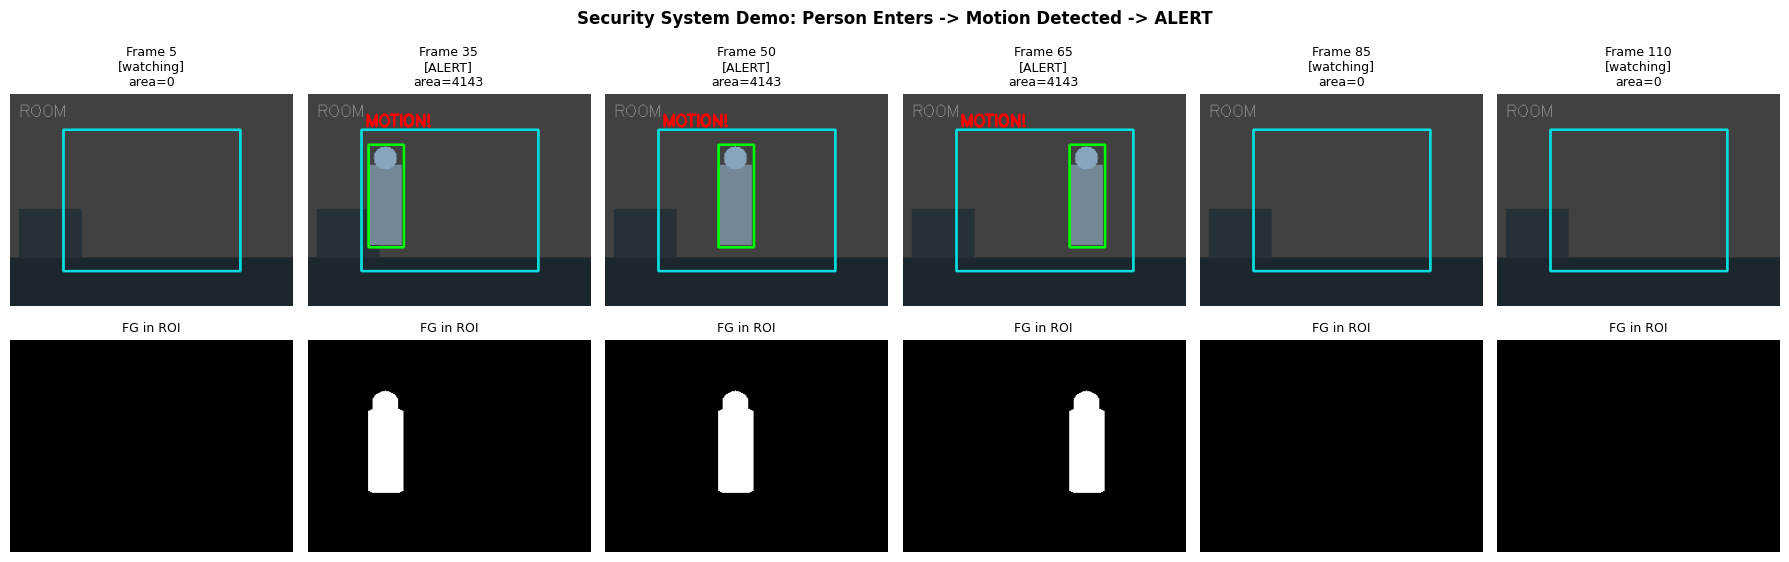

Alert events: 8
  Frame 32: area=3777px
  Frame 38: area=3400px
  Frame 44: area=3794px
  Frame 50: area=4143px
  Frame 56: area=4143px
  Frame 62: area=4143px
  Frame 68: area=4143px
  Frame 74: area=3870px


In [20]:
import cv2, numpy as np, matplotlib.pyplot as plt

H, W = 240, 320

def synthetic_frame(idx):
    """Generate a room scene with a person walking in at frames 30-80."""
    f = np.ones((H, W, 3), dtype=np.uint8) * 65
    # Floor and furniture
    cv2.rectangle(f, (0, 185), (W, H), (45, 38, 28), -1)
    cv2.rectangle(f, (10, 130), (80, 185), (55, 48, 38), -1)
    cv2.putText(f, 'ROOM', (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (140,140,140), 1)
    # Walking person
    if 30 <= idx < 80:
        x = 50 + (idx - 30) * 4
        cv2.rectangle(f, (x, 80), (x+35, 170), (150,135,115), -1)  # body
        cv2.circle(f, (x+17, 72), 13, (190,165,135), -1)           # head
    return f

# Initialize
bg_sub  = cv2.createBackgroundSubtractorMOG2(history=200, varThreshold=40, detectShadows=True)
kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
roi     = np.zeros((H, W), dtype=np.uint8)
cv2.rectangle(roi, (60, 40), (260, 200), 255, -1)

motion_count = 0
alerts = []
saved_frames = []

for i in range(120):
    frame = synthetic_frame(i)

    raw = bg_sub.apply(frame)
    _, fg = cv2.threshold(raw, 200, 255, cv2.THRESH_BINARY)
    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN,  kernel)
    fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, kernel)
    fg = cv2.dilate(fg, kernel, iterations=1)
    fg_roi = cv2.bitwise_and(fg, fg, mask=roi)

    cnts, _ = cv2.findContours(fg_roi, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    area = max((cv2.contourArea(c) for c in cnts), default=0)

    motion_count = motion_count + 1 if area > 400 else 0
    state = 'ALERT' if motion_count >= 3 else 'watching'
    if state == 'ALERT' and (not alerts or i - alerts[-1][0] > 5):
        alerts.append((i, area))

    if i in [5, 35, 50, 65, 85, 110]:
        ann = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        cv2.rectangle(ann, (60,40),(260,200),(0,220,220),2)  # ROI
        if cnts and area > 400:
            x,y,w,h = cv2.boundingRect(max(cnts, key=cv2.contourArea))
            cv2.rectangle(ann,(x,y),(x+w,y+h),(0,255,0),2)
        if state == 'ALERT':
            cv2.putText(ann,'MOTION!',(65,36),cv2.FONT_HERSHEY_SIMPLEX,0.6,(255,0,0),2)
        saved_frames.append((i, ann, fg_roi.copy(), area, state))

n = len(saved_frames)
fig, axes = plt.subplots(2, n, figsize=(n*3, 6))
for col,(idx,rgb,mask,area,state) in enumerate(saved_frames):
    axes[0,col].imshow(rgb)
    axes[0,col].set_title(f'Frame {idx}\n[{state}]\narea={area:.0f}', fontsize=9)
    axes[0,col].axis('off')
    axes[1,col].imshow(mask, cmap='gray')
    axes[1,col].set_title('FG in ROI', fontsize=9)
    axes[1,col].axis('off')

plt.suptitle('Security System Demo: Person Enters -> Motion Detected -> ALERT',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('security_demo.png', dpi=100)
plt.show()

print(f'Alert events: {len(alerts)}')
for fnum, a in alerts:
    print(f'  Frame {fnum}: area={a:.0f}px')

---
# Project Summary

## What We Built

| Component | OpenCV Tool | Role |
|-----------|------------|------|
| Background subtraction | `createBackgroundSubtractorMOG2()` | Detect moving pixels |
| Mask cleaning | `morphologyEx()` OPEN + CLOSE | Remove noise, fill holes |
| ROI masking | `fillPoly()` + `bitwise_and()` | Only monitor the door zone |
| Object detection | `findContours()` + `boundingRect()` | Locate and size objects |
| Alert logic | Custom state machine | Min-frames + cooldown filter |
| Video saving | `VideoWriter` | Auto-save motion clips |
| Event logging | `csv` module | Timestamped record of all events |

## Key Tuning Parameters

```python
MIN_CONTOUR_AREA = 1000  # increase -> fewer false positives from small movements
MIN_ALERT_FRAMES = 4     # increase -> require longer sustained motion to alert
COOLDOWN_SEC     = 8     # reduce  -> more frequent independent alerts
varThreshold     = 50    # in MOG2: increase -> less sensitive to subtle changes
history          = 500   # in MOG2: increase -> slower background adaptation
```

## Quick Start

```python
# Webcam
run_security_system(source=0)

# Video file
run_security_system(source='footage.mp4')
```